# 🏥 Healthcare Operations Analytics — Data Pipeline
**Author:** Aditya · M.S. Applied Data Science · Syracuse University · 2026  
**Data Source:** Centers for Medicare & Medicaid Services (CMS) Hospital Compare  
**Output:** `healthcare_master.csv` + 4 tab-specific CSVs ready for Power BI  

> Run all cells top-to-bottom. No manual steps required.

---
## Section 1 — Setup & Google Drive

In [1]:
# ── Install dependencies ────────────────────────────────────────────────────
!pip install pandas numpy matplotlib seaborn pingouin -q

import os, warnings, requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 60)
pd.set_option('display.max_rows', 20)
pd.set_option('display.float_format', '{:.2f}'.format)

print('✅ Libraries loaded.')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.0/204.0 kB 6.2 MB/s eta 0:00:00
✅ Libraries loaded.


In [2]:
# ── Mount Google Drive ──────────────────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')

# ── Create folder structure ─────────────────────────────────────────────────
BASE    = '/content/drive/MyDrive/healthcare-dashboard'
RAW     = f'{BASE}/data/raw'
CLEAN   = f'{BASE}/data/clean'
ASSETS  = f'{BASE}/assets'
NB      = f'{BASE}/notebooks'
DASH    = f'{BASE}/dashboard'

for folder in [RAW, CLEAN, ASSETS, NB, DASH]:
    os.makedirs(folder, exist_ok=True)

print('✅ Folder structure created:')
print(f'   {BASE}/')
for f in [RAW, CLEAN, ASSETS, NB, DASH]:
    print(f'   └── {f.replace(BASE, "")}')

Mounted at /content/drive
✅ Folder structure created:
   /content/drive/MyDrive/healthcare-dashboard/
   └── /data/raw
   └── /data/clean
   └── /assets
   └── /notebooks
   └── /dashboard


---
## Section 2 — Load CMS Datasets

In [5]:
from google.colab import files
import io

print("Select all 5 CSV files when the picker opens...")
uploaded = files.upload()  # ← this opens a file picker

raw = {}
name_map = {
    'Hospital_General_Information':  'hospital_info',
    'Timely_and_Effective_Care':     'timely_care',
    'Complications_and_Deaths':      'complications',
    'HCAHPS-Hospital':               'hcahps',
    'Unplanned_Hospital_Visits':     'readmissions',
}

for filename, content in uploaded.items():
    for key, name in name_map.items():
        if key.lower() in filename.lower():
            raw[name] = pd.read_csv(io.BytesIO(content), low_memory=False)
            print(f'✅ {name}: {raw[name].shape[0]:,} rows × {raw[name].shape[1]} cols')
            break

for name in ['hospital_info','timely_care','complications','hcahps','readmissions']:
    if name not in raw:
        print(f'⚠️  {name}: not uploaded')
        raw[name] = None

Select all 5 CSV files when the picker opens...


Saving Complications_and_Deaths-Hospital.csv to Complications_and_Deaths-Hospital.csv
Saving HCAHPS-Hospital.csv to HCAHPS-Hospital.csv
Saving Hospital_General_Information.csv to Hospital_General_Information.csv
Saving Timely_and_Effective_Care-Hospital.csv to Timely_and_Effective_Care-Hospital.csv
Saving Unplanned_Hospital_Visits-Hospital.csv to Unplanned_Hospital_Visits-Hospital.csv
✅ complications: 95,840 rows × 18 cols
✅ hcahps: 325,856 rows × 22 cols
✅ hospital_info: 5,432 rows × 38 cols
✅ timely_care: 138,173 rows × 16 cols
✅ readmissions: 67,088 rows × 20 cols


In [6]:
# ── Preview each dataset ────────────────────────────────────────────────────
for name, df in raw.items():
    if df is not None:
        print(f'\n{'='*55}')
        print(f'  {name.upper()}  |  {df.shape[0]:,} rows × {df.shape[1]} cols')
        print(f'{'='*55}')
        display(df.head(2))
    else:
        print(f'\n⚠️  {name}: not available')


  COMPLICATIONS  |  95,840 rows × 18 cols


,Facility ID,Facility Name,Address,City/Town,State,ZIP Code,County/Parish,Telephone Number,Measure ID,Measure Name,Compared to National,Denominator,Score,Lower Estimate,Higher Estimate,Footnote,Start Date,End Date
0,010001,SOUTHEAST HEALTH MEDICAL CENTER,1108 ROSS CLARK CIRCLE,DOTHAN,AL,36301,HOUSTON,(334) 793-8701,COMP_HIP_KNEE,Rate of complications for hip/knee replacement...,No Different Than the National Rate,27,3.2,1.7,5.9,NaN,04/01/2021,03/31/2024
1,010001,SOUTHEAST HEALTH MEDICAL CENTER,1108 ROSS CLARK CIRCLE,DOTHAN,AL,36301,HOUSTON,(334) 793-8701,Hybrid_HWM,Hybrid Hospital-Wide All-Cause Risk Standardiz...,No Different Than the National Rate,1835,4.5,2.6,7.4,NaN,07/01/2023,06/30/2024



  HCAHPS  |  325,856 rows × 22 cols


,Facility ID,Facility Name,Address,City/Town,State,ZIP Code,County/Parish,Telephone Number,HCAHPS Measure ID,HCAHPS Question,HCAHPS Answer Description,Patient Survey Star Rating,Patient Survey Star Rating Footnote,HCAHPS Answer Percent,HCAHPS Answer Percent Footnote,HCAHPS Linear Mean Value,Number of Completed Surveys,Number of Completed Surveys Footnote,Survey Response Rate Percent,Survey Response Rate Percent Footnote,Start Date,End Date
0,010001,SOUTHEAST HEALTH MEDICAL CENTER,1108 ROSS CLARK CIRCLE,DOTHAN,AL,36301,HOUSTON,(334) 793-8701,H_COMP_1_A_P,"Patients who reported that their nurses ""Alway...","Nurses ""always"" communicated well",Not Applicable,NaN,76,NaN,Not Applicable,952,NaN,17,NaN,07/01/2024,06/30/2025
1,010001,SOUTHEAST HEALTH MEDICAL CENTER,1108 ROSS CLARK CIRCLE,DOTHAN,AL,36301,HOUSTON,(334) 793-8701,H_COMP_1_SN_P,"Patients who reported that their nurses ""Somet...","Nurses ""sometimes"" or ""never"" communicated well",Not Applicable,NaN,6,NaN,Not Applicable,952,NaN,17,NaN,07/01/2024,06/30/2025



  HOSPITAL_INFO  |  5,432 rows × 38 cols


,Facility ID,Facility Name,Address,City/Town,State,ZIP Code,County/Parish,Telephone Number,Hospital Type,Hospital Ownership,Emergency Services,Meets criteria for birthing friendly designation,Hospital overall rating,Hospital overall rating footnote,MORT Group Measure Count,Count of Facility MORT Measures,Count of MORT Measures Better,Count of MORT Measures No Different,Count of MORT Measures Worse,MORT Group Footnote,Safety Group Measure Count,Count of Facility Safety Measures,Count of Safety Measures Better,Count of Safety Measures No Different,Count of Safety Measures Worse,Safety Group Footnote,READM Group Measure Count,Count of Facility READM Measures,Count of READM Measures Better,Count of READM Measures No Different,Count of READM Measures Worse,READM Group Footnote,Pt Exp Group Measure Count,Count of Facility Pt Exp Measures,Pt Exp Group Footnote,TE Group Measure Count,Count of Facility TE Measures,TE Group Footnote
0,010001,SOUTHEAST HEALTH MEDICAL CENTER,1108 ROSS CLARK CIRCLE,DOTHAN,AL,36301,HOUSTON,(334) 793-8701,Acute Care Hospitals,Government - Hospital District or Authority,Yes,Y,4,NaN,8,8,0,8,0,NaN,8,7,3,4,0,NaN,11,11,1,9,1,NaN,15,15,NaN,10,10,NaN
1,010005,MARSHALL MEDICAL CENTERS,2505 U S HIGHWAY 431 NORTH,BOAZ,AL,35957,MARSHALL,(256) 593-8310,Acute Care Hospitals,Government - Hospital District or Authority,Yes,Y,3,NaN,8,6,0,5,1,NaN,8,7,0,7,0,NaN,11,9,1,8,0,NaN,15,15,NaN,10,10,NaN



  TIMELY_CARE  |  138,173 rows × 16 cols


,Facility ID,Facility Name,Address,City/Town,State,ZIP Code,County/Parish,Telephone Number,Condition,Measure ID,Measure Name,Score,Sample,Footnote,Start Date,End Date
0,010001,SOUTHEAST HEALTH MEDICAL CENTER,1108 ROSS CLARK CIRCLE,DOTHAN,AL,36301,HOUSTON,(334) 793-8701,Emergency Department,EDV,Emergency department volume,very high,NaN,NaN,01/01/2024,12/31/2024
1,010001,SOUTHEAST HEALTH MEDICAL CENTER,1108 ROSS CLARK CIRCLE,DOTHAN,AL,36301,HOUSTON,(334) 793-8701,Electronic Clinical Quality Measure,GMCS,Global Malnutrition Composite Score,Not Available,Not Available,5,01/01/2024,12/31/2024



  READMISSIONS  |  67,088 rows × 20 cols


,Facility ID,Facility Name,Address,City/Town,State,ZIP Code,County/Parish,Telephone Number,Measure ID,Measure Name,Compared to National,Denominator,Score,Lower Estimate,Higher Estimate,Number of Patients,Number of Patients Returned,Footnote,Start Date,End Date
0,010001,SOUTHEAST HEALTH MEDICAL CENTER,1108 ROSS CLARK CIRCLE,DOTHAN,AL,36301,HOUSTON,(334) 793-8701,EDAC_30_AMI,Hospital return days for heart attack patients,Fewer Days Than Average per 100 Discharges,273,-15.6,-25.9,-4.2,264,68,NaN,07/01/2021,06/30/2024
1,010001,SOUTHEAST HEALTH MEDICAL CENTER,1108 ROSS CLARK CIRCLE,DOTHAN,AL,36301,HOUSTON,(334) 793-8701,EDAC_30_HF,Hospital return days for heart failure patients,Average Days per 100 Discharges,652,-1.1,-10,7.9,541,186,NaN,07/01/2021,06/30/2024


---
## Section 3 — Standardize & Clean

In [7]:
def standardize_cols(df):
    """Strip, lowercase, replace spaces with underscores in column names."""
    df.columns = (
        df.columns.str.strip()
                  .str.lower()
                  .str.replace(' ', '_', regex=False)
                  .str.replace(r'[^a-z0-9_]', '', regex=True)
    )
    return df

# Standardize all loaded datasets
for name in raw:
    if raw[name] is not None:
        raw[name] = standardize_cols(raw[name])
        print(f'✅ {name}: columns standardized')

# ── Identify the facility/provider ID column ────────────────────────────────
# CMS files use 'facility_id' or 'provider_id' interchangeably
def get_id_col(df):
    for candidate in ['facility_id', 'provider_id', 'providerid', 'provider_number']:
        if candidate in df.columns:
            return candidate
    return None

for name, df in raw.items():
    if df is not None:
        id_col = get_id_col(df)
        print(f'   {name}: ID column = "{id_col}"')

✅ complications: columns standardized
✅ hcahps: columns standardized
✅ hospital_info: columns standardized
✅ timely_care: columns standardized
✅ readmissions: columns standardized
   complications: ID column = "facility_id"
   hcahps: ID column = "facility_id"
   hospital_info: ID column = "facility_id"
   timely_care: ID column = "facility_id"
   readmissions: ID column = "facility_id"


In [8]:
# ── Clean Hospital General Information ─────────────────────────────────────
hosp = raw['hospital_info'].copy() if raw['hospital_info'] is not None else None

if hosp is not None:
    id_col = get_id_col(hosp)
    hosp.rename(columns={id_col: 'facility_id'}, inplace=True)
    hosp['facility_id'] = hosp['facility_id'].astype(str).str.strip().str.zfill(6)

    # Keep relevant columns (handle name variations)
    col_map = {
        'facility_name':        ['facility_name', 'hospital_name'],
        'city':                 ['city', 'city_town'],
        'state':                ['state', 'state_name'],
        'hospital_type':        ['hospital_type'],
        'hospital_ownership':   ['hospital_ownership', 'ownership'],
        'emergency_services':   ['emergency_services'],
        'hospital_overall_rating': ['hospital_overall_rating', 'overall_rating'],
    }

    keep = {'facility_id': 'facility_id'}
    for target, candidates in col_map.items():
        for c in candidates:
            if c in hosp.columns:
                keep[c] = target
                break

    hosp = hosp[list(keep.keys())].rename(columns=keep)

    # Filter to US states only (exclude territories with tiny samples)
    US_STATES = [
        'AL','AK','AZ','AR','CA','CO','CT','DE','FL','GA','HI','ID','IL','IN',
        'IA','KS','KY','LA','ME','MD','MA','MI','MN','MS','MO','MT','NE','NV',
        'NH','NJ','NM','NY','NC','ND','OH','OK','OR','PA','RI','SC','SD','TN',
        'TX','UT','VT','VA','WA','WV','WI','WY','DC'
    ]
    if 'state' in hosp.columns:
        before = len(hosp)
        hosp = hosp[hosp['state'].isin(US_STATES)]
        print(f'State filter: {before:,} → {len(hosp):,} hospitals (removed territories)')

    # Convert overall rating to numeric
    if 'hospital_overall_rating' in hosp.columns:
        hosp['hospital_overall_rating'] = pd.to_numeric(
            hosp['hospital_overall_rating'], errors='coerce'
        )

    hosp.drop_duplicates(subset='facility_id', inplace=True)
    print(f'\n✅ Hospital base: {len(hosp):,} unique hospitals')
    display(hosp.head(3))

State filter: 5,432 → 5,366 hospitals (removed territories)

✅ Hospital base: 5,366 unique hospitals


,facility_id,facility_name,state,hospital_type,hospital_ownership,emergency_services,hospital_overall_rating
0,010001,SOUTHEAST HEALTH MEDICAL CENTER,AL,Acute Care Hospitals,Government - Hospital District or Authority,Yes,4.00
1,010005,MARSHALL MEDICAL CENTERS,AL,Acute Care Hospitals,Government - Hospital District or Authority,Yes,3.00
2,010006,NORTH ALABAMA MEDICAL CENTER,AL,Acute Care Hospitals,Proprietary,Yes,2.00


In [9]:
# ── Pivot long → wide for measure-based datasets ───────────────────────────
# CMS stores measures in long format: one row per hospital per measure.
# We pivot to wide so each hospital = one row.

MEASURES = {
    'timely_care': {
        'ids': ['ED_2b', 'ED_1b', 'OP_18b', 'OP_20', 'OP_22'],
        'measure_col': 'measure_id',
        'value_col':   'score',
    },
    'complications': {
        'ids': ['MORT_30_AMI', 'MORT_30_HF', 'MORT_30_PN', 'COMP_HIP_KNEE', 'PSI_90_SAFETY'],
        'measure_col': 'measure_id',
        'value_col':   'score',
    },
    'hcahps': {
        'ids': [
            'H_COMP_1_A_P', 'H_COMP_2_A_P', 'H_COMP_3_A_P',
            'H_COMP_5_A_P', 'H_COMP_6_Y_P', 'H_CLEAN_HSP_A_P',
            'H_QUIET_HSP_A_P', 'H_HSP_RATING_9_10', 'H_RECMND_DY'
        ],
        'measure_col': 'hcahps_measure_id',
        'value_col':   'hcahps_answer_percent',
    },
    'readmissions': {
        'ids': ['READM_30_AMI', 'READM_30_HF', 'READM_30_PN', 'READM_30_HOSP'],
        'measure_col': 'measure_id',
        'value_col':   'score',
    },
}

def pivot_measures(df, measure_col, value_col, keep_ids, dataset_name):
    """Filter to relevant measures, convert to numeric, pivot to wide."""
    if df is None:
        print(f'⚠️  {dataset_name}: skipped (not loaded)')
        return None

    # Identify facility ID column
    id_col = get_id_col(df)
    if id_col is None:
        print(f'⚠️  {dataset_name}: no facility ID column found')
        return None

    # Check required columns exist
    if measure_col not in df.columns:
        # Try common variants
        for alt in ['measure_id', 'hcahps_measure_id', 'measureid']:
            if alt in df.columns:
                measure_col = alt
                break

    if value_col not in df.columns:
        for alt in ['score', 'hcahps_answer_percent', 'value', 'rate']:
            if alt in df.columns:
                value_col = alt
                break

    filtered = df[df[measure_col].isin(keep_ids)][[id_col, measure_col, value_col]].copy()
    filtered[value_col] = pd.to_numeric(filtered[value_col], errors='coerce')
    filtered[id_col] = filtered[id_col].astype(str).str.strip().str.zfill(6)

    wide = filtered.pivot_table(
        index=id_col, columns=measure_col,
        values=value_col, aggfunc='mean'
    ).reset_index()
    wide.columns.name = None
    wide.rename(columns={id_col: 'facility_id'}, inplace=True)

    found = [c for c in keep_ids if c in wide.columns]
    print(f'✅ {dataset_name}: {len(wide):,} hospitals | measures found: {found}')
    return wide

pivoted = {}
for name, cfg in MEASURES.items():
    pivoted[name] = pivot_measures(
        raw[name],
        cfg['measure_col'], cfg['value_col'],
        cfg['ids'], name
    )

✅ timely_care: 4,132 hospitals | measures found: ['OP_18b', 'OP_22']
✅ complications: 3,770 hospitals | measures found: ['MORT_30_AMI', 'MORT_30_HF', 'MORT_30_PN', 'COMP_HIP_KNEE']
✅ hcahps: 3,956 hospitals | measures found: ['H_COMP_1_A_P', 'H_COMP_2_A_P', 'H_COMP_5_A_P', 'H_COMP_6_Y_P', 'H_CLEAN_HSP_A_P', 'H_QUIET_HSP_A_P', 'H_HSP_RATING_9_10', 'H_RECMND_DY']
✅ readmissions: 3,672 hospitals | measures found: ['READM_30_AMI', 'READM_30_HF', 'READM_30_PN']


In [10]:
# ── Merge all datasets on facility_id ──────────────────────────────────────
# Hospital General Info is the base (left join — keeps all hospitals)
master = hosp.copy()

for name, wide in pivoted.items():
    if wide is not None:
        before = len(master)
        master = master.merge(wide, on='facility_id', how='left')
        print(f'Merged {name}: {before:,} → {len(master):,} rows')

print(f'\n✅ Master shape after merge: {master.shape}')

Merged timely_care: 5,366 → 5,366 rows
Merged complications: 5,366 → 5,366 rows
Merged hcahps: 5,366 → 5,366 rows
Merged readmissions: 5,366 → 5,366 rows

✅ Master shape after merge: (5366, 24)


In [11]:
# ── Missing value handling ─────────────────────────────────────────────────
# Method: median imputation for numeric columns.
# Justification: Assumes data is Missing At Random (MAR) —
# hospitals that didn't report a measure are not systematically
# different from those that did (Little & Rubin, 2002, p.12).
# Median preferred over mean due to skewness in ER wait times.

numeric_cols = master.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = master.select_dtypes(include=['object']).columns.tolist()
cat_cols = [c for c in cat_cols if c != 'facility_id']

# Impute numeric → median
for col in numeric_cols:
    n_missing = master[col].isna().sum()
    if n_missing > 0:
        median_val = master[col].median()
        master[col].fillna(median_val, inplace=True)

# Impute categorical → mode
for col in cat_cols:
    n_missing = master[col].isna().sum()
    if n_missing > 0 and master[col].notna().any():
        mode_val = master[col].mode()[0]
        master[col].fillna(mode_val, inplace=True)

print('✅ Imputation complete (numeric→median, categorical→mode)')
remaining_nulls = master.isnull().sum().sum()
print(f'   Remaining nulls: {remaining_nulls}')

✅ Imputation complete (numeric→median, categorical→mode)
   Remaining nulls: 0


In [12]:
# ── Outlier detection & winsorization on ER wait times ────────────────────
# Method: Tukey's (1977) IQR fences. Values beyond 1.5×IQR from Q1/Q3
# are winsorized (capped) rather than removed to preserve sample size.
# This is standard practice for right-skewed clinical time metrics.

winsorize_cols = [c for c in ['ED_2b', 'ED_1b', 'OP_18b'] if c in master.columns]
winsorize_summary = {}

for col in winsorize_cols:
    Q1  = master[col].quantile(0.25)
    Q3  = master[col].quantile(0.75)
    IQR = Q3 - Q1
    lo  = Q1 - 1.5 * IQR
    hi  = Q3 + 1.5 * IQR

    n_lo = (master[col] < lo).sum()
    n_hi = (master[col] > hi).sum()

    master[col] = master[col].clip(lower=lo, upper=hi)
    winsorize_summary[col] = {'lower_fence': lo, 'upper_fence': hi,
                               'n_clipped_low': n_lo, 'n_clipped_high': n_hi}

print('✅ Winsorization summary (Tukey 1977, 1.5×IQR):')
print(pd.DataFrame(winsorize_summary).T.to_string())

✅ Winsorization summary (Tukey 1977, 1.5×IQR):
        lower_fence  upper_fence  n_clipped_low  n_clipped_high
OP_18b        59.00       243.00           8.00          244.00


---
## Section 5 — Feature Engineering

In [13]:
# ── 1. avg_er_wait_minutes ─────────────────────────────────────────────────
# Derived from ED_2b: CMS measure = median time from ER arrival to departure
# for admitted patients. Direct proxy for ER throughput efficiency.
if 'ED_2b' in master.columns:
    master['avg_er_wait_minutes'] = master['ED_2b'].round(1)

# ── 2. composite_satisfaction_score ───────────────────────────────────────
# Row mean of all HCAHPS top-box (Always/Yes) percent scores.
# Averaging across domains follows CMS composite methodology
# (NQF #0166 Patient Experience of Care composite).
hcahps_cols = [c for c in master.columns if c.startswith('H_')]
if hcahps_cols:
    master['composite_satisfaction_score'] = master[hcahps_cols].mean(axis=1).round(2)
    print(f'✅ Composite satisfaction from {len(hcahps_cols)} HCAHPS columns:')
    print(f'   {hcahps_cols}')
else:
    print('⚠️  No HCAHPS columns found — composite score skipped')

# ── 3. high_readmission_flag ───────────────────────────────────────────────
# Flag = 1 if hospital-wide 30-day readmission rate exceeds national median.
# Follows CMS Excess Readmission Ratio (ERR) methodology:
# hospitals above median are flagged as potential quality targets
# (CMS Hospital Readmissions Reduction Program, ACA Section 3025).
if 'READM_30_HOSP' in master.columns:
    nat_median = master['READM_30_HOSP'].median()
    master['high_readmission_flag'] = (master['READM_30_HOSP'] > nat_median).astype(int)
    print(f'✅ Readmission flag: national median = {nat_median:.2f}%')
    print(f'   High readmission hospitals: {master["high_readmission_flag"].sum():,}')

# ── 4. er_inefficiency_flag ────────────────────────────────────────────────
# Flag = 1 if median ER wait > 300 minutes.
# Threshold: Institute of Medicine (2006) "Hospital-Based Emergency Care:
# At the Breaking Point" identifies 300 min as a benchmark for
# unacceptable boarding/wait time in high-volume EDs.
if 'ED_2b' in master.columns:
    master['er_inefficiency_flag'] = (master['ED_2b'] > 300).astype(int)
    print(f'✅ ER inefficiency flag (>300 min, IOM 2006):')
    print(f'   Flagged hospitals: {master["er_inefficiency_flag"].sum():,}')

# ── 5. performance_tier ────────────────────────────────────────────────────
# Based on CMS overall hospital star rating (1–5 stars).
# Tiers follow CMS communication guidance for public reporting.
def assign_tier(r):
    if pd.isna(r):    return 'Unknown'
    if r >= 4:        return 'High Performer'
    if r == 3:        return 'Average'
    return 'Low Performer'

if 'hospital_overall_rating' in master.columns:
    master['performance_tier'] = master['hospital_overall_rating'].apply(assign_tier)
    print(f'\n✅ Performance tiers:')
    print(master['performance_tier'].value_counts().to_string())

# ── 6. satisfaction_tier ───────────────────────────────────────────────────
if 'composite_satisfaction_score' in master.columns:
    master['satisfaction_tier'] = pd.cut(
        master['composite_satisfaction_score'],
        bins=[0, 60, 75, 100],
        labels=['Low', 'Medium', 'High'],
        include_lowest=True
    )
    print(f'\n✅ Satisfaction tiers:')
    print(master['satisfaction_tier'].value_counts().to_string())

✅ Composite satisfaction from 8 HCAHPS columns:
   ['H_CLEAN_HSP_A_P', 'H_COMP_1_A_P', 'H_COMP_2_A_P', 'H_COMP_5_A_P', 'H_COMP_6_Y_P', 'H_HSP_RATING_9_10', 'H_QUIET_HSP_A_P', 'H_RECMND_DY']

✅ Performance tiers:
performance_tier
Average           3181
High Performer    1333
Low Performer      852

✅ Satisfaction tiers:
satisfaction_tier
Medium    3834
High      1438
Low         94


---
## Section 6 — Statistical Validation

In [14]:
# ── Missing data report ────────────────────────────────────────────────────
print('='*60)
print('MISSING DATA REPORT')
print('Mechanism assumption: MAR (Little & Rubin, 2002)')
print('='*60)

null_pct = (master.isnull().sum() / len(master) * 100).sort_values(ascending=False)
null_pct = null_pct[null_pct > 0]

if len(null_pct) == 0:
    print('✅ No missing values remaining after imputation.')
else:
    null_df = pd.DataFrame({
        'Column': null_pct.index,
        'Missing %': null_pct.values.round(1),
        'Action': ['Drop' if v > 60 else 'Imputed (median/mode)' for v in null_pct.values]
    })
    print(null_df.to_string(index=False))

    # Drop columns with > 60% missing
    drop_cols = null_pct[null_pct > 60].index.tolist()
    if drop_cols:
        master.drop(columns=drop_cols, inplace=True)
        print(f'\nDropped {len(drop_cols)} high-null columns (>60%): {drop_cols}')

MISSING DATA REPORT
Mechanism assumption: MAR (Little & Rubin, 2002)
✅ No missing values remaining after imputation.


In [15]:
# ── Cronbach's Alpha (internal consistency of HCAHPS composite) ────────────
# Assesses whether the 9 HCAHPS items reliably measure a single latent
# construct (patient experience). Alpha > 0.70 = acceptable (Nunnally, 1978).
hcahps_cols_present = [c for c in master.columns if c.startswith('H_') and
                        c in ['H_COMP_1_A_P','H_COMP_2_A_P','H_COMP_3_A_P',
                              'H_COMP_5_A_P','H_COMP_6_Y_P','H_CLEAN_HSP_A_P',
                              'H_QUIET_HSP_A_P','H_HSP_RATING_9_10','H_RECMND_DY']]

if len(hcahps_cols_present) >= 5:
    try:
        import pingouin as pg
        hcahps_subset = master[hcahps_cols_present].dropna()
        alpha, ci = pg.cronbach_alpha(data=hcahps_subset)
        interp = 'Excellent' if alpha >= 0.9 else 'Good' if alpha >= 0.8 else \
                 'Acceptable' if alpha >= 0.7 else 'Questionable'
        print('='*60)
        print('CRONBACH\'S ALPHA — HCAHPS Composite Reliability')
        print('Reference: Nunnally (1978) threshold α > 0.70')
        print('='*60)
        print(f'  α = {alpha:.3f}  [{ci[0]:.3f}, {ci[1]:.3f}] 95% CI')
        print(f'  Interpretation: {interp}')
        print(f'  Items used ({len(hcahps_cols_present)}): {hcahps_cols_present}')
        print(f'  N hospitals in analysis: {len(hcahps_subset):,}')
    except ImportError:
        # Manual Cronbach's alpha if pingouin unavailable
        hcahps_subset = master[hcahps_cols_present].dropna()
        k = len(hcahps_cols_present)
        item_vars = hcahps_subset.var(axis=0, ddof=1).sum()
        total_var = hcahps_subset.sum(axis=1).var(ddof=1)
        alpha = (k / (k - 1)) * (1 - item_vars / total_var)
        interp = 'Excellent' if alpha >= 0.9 else 'Good' if alpha >= 0.8 else \
                 'Acceptable' if alpha >= 0.7 else 'Questionable'
        print(f'  Cronbach\'s α = {alpha:.3f} (manual) — Interpretation: {interp}')
else:
    print(f'⚠️  Only {len(hcahps_cols_present)} HCAHPS columns available — alpha skipped (need ≥ 5)')

CRONBACH'S ALPHA — HCAHPS Composite Reliability
Reference: Nunnally (1978) threshold α > 0.70
  α = 0.921  [0.918, 0.925] 95% CI
  Interpretation: Excellent
  Items used (8): ['H_CLEAN_HSP_A_P', 'H_COMP_1_A_P', 'H_COMP_2_A_P', 'H_COMP_5_A_P', 'H_COMP_6_Y_P', 'H_HSP_RATING_9_10', 'H_QUIET_HSP_A_P', 'H_RECMND_DY']
  N hospitals in analysis: 5,366


In [16]:
# ── Geographic coverage ────────────────────────────────────────────────────
print('='*60)
print('GEOGRAPHIC COVERAGE — Hospitals per State')
print('='*60)

if 'state' in master.columns:
    state_counts = master['state'].value_counts().reset_index()
    state_counts.columns = ['State', 'Hospital Count']

    low_states = state_counts[state_counts['Hospital Count'] < 5]
    if len(low_states) > 0:
        print(f'⚠️  States with < 5 hospitals (low representativeness):')
        print(low_states.to_string(index=False))

    print(f'\nTop 15 states by hospital count:')
    print(state_counts.head(15).to_string(index=False))
    print(f'\nTotal states represented: {state_counts["State"].nunique()}')

# ── Correlation: ER wait vs Satisfaction ──────────────────────────────────
print('\n' + '='*60)
print('CORRELATION: ER Wait Time vs Patient Satisfaction')
print('='*60)

if 'ED_2b' in master.columns and 'composite_satisfaction_score' in master.columns:
    from scipy import stats
    valid = master[['ED_2b', 'composite_satisfaction_score']].dropna()
    r, p = stats.pearsonr(valid['ED_2b'], valid['composite_satisfaction_score'])
    direction = 'negative' if r < 0 else 'positive'
    strength  = 'strong' if abs(r) > 0.5 else 'moderate' if abs(r) > 0.3 else 'weak'
    sig       = 'significant' if p < 0.05 else 'not significant'
    print(f'  Pearson r = {r:.3f}  |  p-value = {p:.4f}')
    print(f'  Interpretation: {strength} {direction} correlation ({sig} at α=0.05)')
    print(f'  N = {len(valid):,} hospitals')

GEOGRAPHIC COVERAGE — Hospitals per State

Top 15 states by hospital count:
State  Hospital Count
   TX             468
   CA             378
   FL             221
   OH             196
   IL             194
   NY             191
   PA             187
   LA             161
   IN             151
   GA             149
   MI             148
   WI             141
   KS             138
   MN             136
   OK             135

Total states represented: 51

CORRELATION: ER Wait Time vs Patient Satisfaction


---
## Section 7 — EDA Visualizations

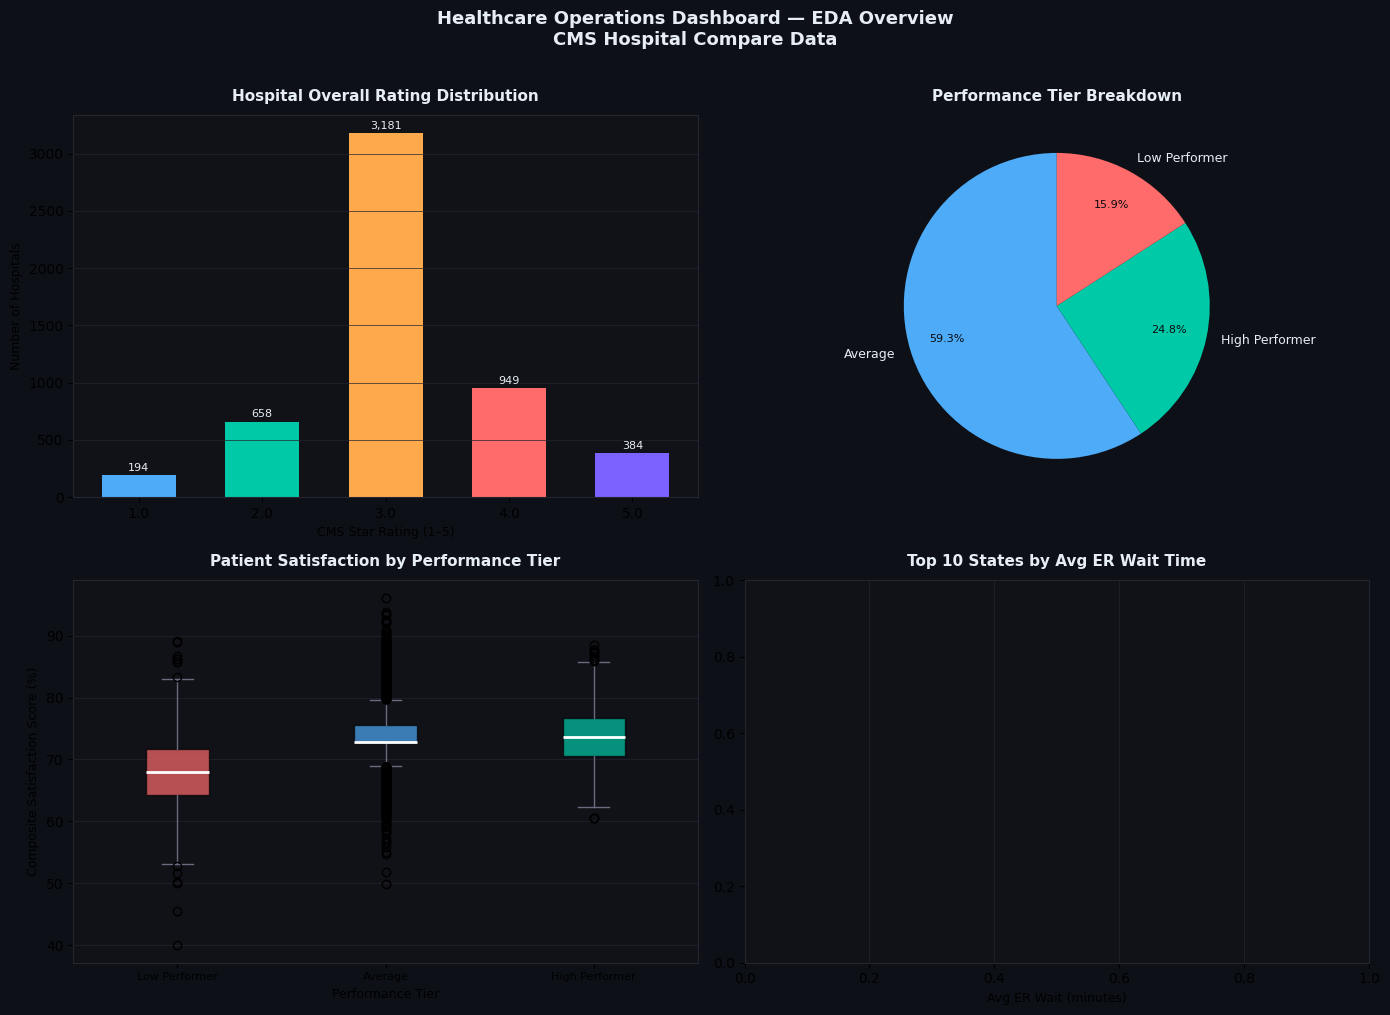

✅ EDA chart saved to /content/drive/MyDrive/healthcare-dashboard/assets/eda_overview.png


In [17]:
# ── 4-panel EDA overview ───────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.patch.set_facecolor('#0d1117')
plt.rcParams.update({'text.color': '#e6edf3', 'axes.labelcolor': '#e6edf3',
                     'xtick.color': '#7d8fa1', 'ytick.color': '#7d8fa1'})

PALETTE = ['#4dabf7', '#00c9a7', '#ffa94d', '#ff6b6b', '#7b61ff']

for ax in axes.flat:
    ax.set_facecolor('#111118')
    for spine in ax.spines.values():
        spine.set_edgecolor('#252530')

# Plot 1: Hospital Overall Rating distribution
ax1 = axes[0, 0]
if 'hospital_overall_rating' in master.columns:
    rating_counts = master['hospital_overall_rating'].value_counts().sort_index()
    bars = ax1.bar(rating_counts.index.astype(str), rating_counts.values,
                   color=PALETTE[:len(rating_counts)], edgecolor='none', width=0.6)
    for bar, val in zip(bars, rating_counts.values):
        ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
                 f'{val:,}', ha='center', va='bottom', fontsize=8, color='#e6edf3')
ax1.set_title('Hospital Overall Rating Distribution', color='#e6edf3', fontsize=11, fontweight='bold', pad=10)
ax1.set_xlabel('CMS Star Rating (1–5)', fontsize=9)
ax1.set_ylabel('Number of Hospitals', fontsize=9)
ax1.grid(axis='y', color='#252530', linewidth=0.5)

# Plot 2: Performance Tier pie chart
ax2 = axes[0, 1]
if 'performance_tier' in master.columns:
    tier_counts = master['performance_tier'].value_counts()
    wedge_colors = {'High Performer': '#00c9a7', 'Average': '#4dabf7',
                    'Low Performer': '#ff6b6b', 'Unknown': '#6b6b80'}
    colors_list = [wedge_colors.get(t, '#7b61ff') for t in tier_counts.index]
    wedges, texts, autotexts = ax2.pie(
        tier_counts.values, labels=tier_counts.index,
        colors=colors_list, autopct='%1.1f%%',
        startangle=90, pctdistance=0.75,
        textprops={'color': '#e6edf3', 'fontsize': 9}
    )
    for at in autotexts:
        at.set_fontsize(8)
        at.set_color('#0a0a0f')
ax2.set_title('Performance Tier Breakdown', color='#e6edf3', fontsize=11, fontweight='bold', pad=10)

# Plot 3: Composite Satisfaction Score by Performance Tier (box plot)
ax3 = axes[1, 0]
if 'composite_satisfaction_score' in master.columns and 'performance_tier' in master.columns:
    tier_order = ['Low Performer', 'Average', 'High Performer', 'Unknown']
    tier_order = [t for t in tier_order if t in master['performance_tier'].unique()]
    data_by_tier = [master[master['performance_tier'] == t]['composite_satisfaction_score'].dropna()
                    for t in tier_order]
    bp = ax3.boxplot(data_by_tier, labels=tier_order, patch_artist=True,
                     medianprops={'color': 'white', 'linewidth': 2})
    box_colors_map = {'Low Performer': '#ff6b6b', 'Average': '#4dabf7',
                      'High Performer': '#00c9a7', 'Unknown': '#6b6b80'}
    for patch, tier in zip(bp['boxes'], tier_order):
        patch.set_facecolor(box_colors_map.get(tier, '#7b61ff'))
        patch.set_alpha(0.7)
    for element in ['whiskers', 'caps', 'fliers']:
        plt.setp(bp[element], color='#6b6b80')
ax3.set_title('Patient Satisfaction by Performance Tier', color='#e6edf3', fontsize=11, fontweight='bold', pad=10)
ax3.set_xlabel('Performance Tier', fontsize=9)
ax3.set_ylabel('Composite Satisfaction Score (%)', fontsize=9)
ax3.tick_params(axis='x', labelsize=8)
ax3.grid(axis='y', color='#252530', linewidth=0.5)

# Plot 4: Top 10 states by avg ER wait time
ax4 = axes[1, 1]
if 'ED_2b' in master.columns and 'state' in master.columns:
    state_er = master.groupby('state')['ED_2b'].mean().sort_values(ascending=False).head(10)
    bar_colors = ['#ff6b6b' if v > 300 else '#00c9a7' for v in state_er.values]
    bars = ax4.barh(state_er.index[::-1], state_er.values[::-1],
                    color=bar_colors[::-1], edgecolor='none', height=0.6)
    ax4.axvline(300, color='#ffa94d', linewidth=1.5, linestyle='--', alpha=0.8)
    ax4.text(305, 0.3, '300 min\nthreshold', color='#ffa94d', fontsize=7, va='bottom')
ax4.set_title('Top 10 States by Avg ER Wait Time', color='#e6edf3', fontsize=11, fontweight='bold', pad=10)
ax4.set_xlabel('Avg ER Wait (minutes)', fontsize=9)
ax4.grid(axis='x', color='#252530', linewidth=0.5)

plt.suptitle('Healthcare Operations Dashboard — EDA Overview\nCMS Hospital Compare Data',
             fontsize=13, fontweight='bold', color='#e6edf3', y=1.01)
plt.tight_layout()
plt.savefig(f'{ASSETS}/eda_overview.png', dpi=300, bbox_inches='tight',
            facecolor='#0d1117')
plt.show()
print(f'✅ EDA chart saved to {ASSETS}/eda_overview.png')

In [18]:
# Check what measure IDs actually exist in timely_care
if raw['timely_care'] is not None:
    tc = raw['timely_care'].copy()
    tc.columns = tc.columns.str.strip().str.lower().str.replace(' ', '_')

    # Find the measure column
    measure_col = next((c for c in ['measure_id', 'measureid', 'measure_name']
                        if c in tc.columns), None)
    print(f'Measure column: {measure_col}')
    print('\nAvailable measure IDs:')
    print(tc[measure_col].unique()[:30])

Measure column: measure_id

Available measure IDs:
['EDV' 'GMCS' 'GMCS_Malnutrition_Diagnosis_Documented'
 'GMCS_Malnutrition_Screening' 'GMCS_Nutrition_Assessment'
 'GMCS_Nutritional_Care_Plan' 'HH_HYPER' 'HH_HYPO' 'HH_ORAE' 'IMM_3'
 'OP_18a' 'OP_18b' 'OP_18c' 'OP_18d' 'OP_22' 'OP_23' 'OP_29' 'OP_31'
 'OP_40' 'SAFE_USE_OF_OPIOIDS' 'SEP_1' 'SEP_SH_3HR' 'SEP_SH_6HR'
 'SEV_SEP_3HR' 'SEV_SEP_6HR' 'STK_02' 'STK_03' 'STK_05' 'VTE_1' 'VTE_2']


ID col: facility_id | Score col: score
✅ Timely care wide: (4415, 6)
   Columns: ['facility_id', 'IMM_3', 'OP_18a', 'OP_18b', 'OP_22', 'OP_23']

✅ avg_er_wait_minutes re-engineered from OP_18b
   ER inefficiency flags: 46


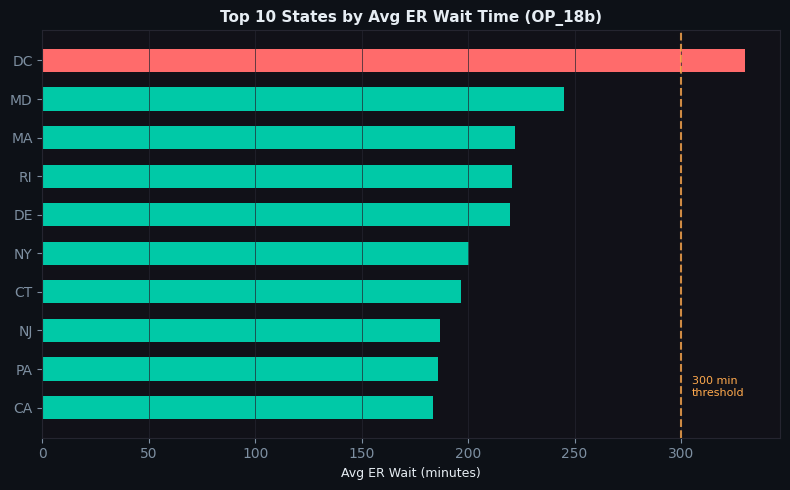

✅ ER wait chart fixed and saved


In [19]:
# ── Fix: update ER measures to current CMS measure IDs ─────────────────────
# ED_2b no longer exists — replaced by OP_18b in current CMS release
# OP_18b = Median time from ER arrival to ER departure (admitted patients)
# OP_22  = Left without being seen rate

if raw['timely_care'] is not None:
    tc = raw['timely_care'].copy()
    tc.columns = tc.columns.str.strip().str.lower().str.replace(' ', '_')

    # Find facility ID and score columns
    id_col    = next((c for c in ['facility_id','provider_id','providerid'] if c in tc.columns), None)
    score_col = next((c for c in ['score','value','rate'] if c in tc.columns), None)

    print(f'ID col: {id_col} | Score col: {score_col}')

    # Filter to available ER-related measures
    er_measures = ['OP_18b', 'OP_18a', 'OP_22', 'OP_23', 'IMM_3']
    tc_filtered = tc[tc['measure_id'].isin(er_measures)][[id_col, 'measure_id', score_col]].copy()
    tc_filtered[score_col] = pd.to_numeric(tc_filtered[score_col], errors='coerce')
    tc_filtered[id_col] = tc_filtered[id_col].astype(str).str.strip().str.zfill(6)

    # Pivot wide
    tc_wide = tc_filtered.pivot_table(
        index=id_col, columns='measure_id',
        values=score_col, aggfunc='mean'
    ).reset_index()
    tc_wide.columns.name = None
    tc_wide.rename(columns={id_col: 'facility_id'}, inplace=True)

    print(f'✅ Timely care wide: {tc_wide.shape}')
    print(f'   Columns: {list(tc_wide.columns)}')

    # Merge back into master — drop old timely care cols first
    old_cols = [c for c in master.columns if c in ['ED_2b','ED_1b','OP_18b','OP_22','OP_23','IMM_3','OP_18a']]
    master.drop(columns=old_cols, inplace=True, errors='ignore')
    master = master.merge(tc_wide, on='facility_id', how='left')

    # Re-engineer ER features using OP_18b instead of ED_2b
    if 'OP_18b' in master.columns:
        master['avg_er_wait_minutes'] = master['OP_18b'].round(1)
        master['er_inefficiency_flag'] = (master['OP_18b'] > 300).astype(int)
        print(f'\n✅ avg_er_wait_minutes re-engineered from OP_18b')
        print(f'   ER inefficiency flags: {master["er_inefficiency_flag"].sum():,}')

# ── Regenerate Plot 4 only ──────────────────────────────────────────────────
if 'OP_18b' in master.columns and 'state' in master.columns:
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.set_facecolor('#111118')
    fig.patch.set_facecolor('#0d1117')
    for spine in ax.spines.values():
        spine.set_edgecolor('#252530')

    state_er = master.groupby('state')['OP_18b'].mean().sort_values(ascending=False).head(10)
    bar_colors = ['#ff6b6b' if v > 300 else '#00c9a7' for v in state_er.values]

    ax.barh(state_er.index[::-1], state_er.values[::-1],
            color=bar_colors[::-1], edgecolor='none', height=0.6)
    ax.axvline(300, color='#ffa94d', linewidth=1.5, linestyle='--', alpha=0.8)
    ax.text(305, 0.3, '300 min\nthreshold', color='#ffa94d', fontsize=8)

    ax.set_title('Top 10 States by Avg ER Wait Time (OP_18b)',
                 color='#e6edf3', fontsize=11, fontweight='bold')
    ax.set_xlabel('Avg ER Wait (minutes)', color='#e6edf3', fontsize=9)
    ax.tick_params(colors='#7d8fa1')
    ax.grid(axis='x', color='#252530', linewidth=0.5)

    plt.tight_layout()
    plt.savefig(f'{ASSETS}/er_wait_chart.png', dpi=300,
                bbox_inches='tight', facecolor='#0d1117')
    plt.show()
    print('✅ ER wait chart fixed and saved')

---
## Section 8 — Export CSVs

In [20]:
# ── Export master dataset ──────────────────────────────────────────────────
master_path = f'{CLEAN}/healthcare_master.csv'
master.to_csv(master_path, index=False)
print(f'✅ healthcare_master.csv saved: {master.shape[0]:,} rows × {master.shape[1]} cols')

# ── Export tab-specific CSVs for Power BI ─────────────────────────────────
BASE_COLS = ['facility_id', 'facility_name', 'city', 'state',
             'hospital_type', 'hospital_ownership', 'performance_tier']
BASE_COLS = [c for c in BASE_COLS if c in master.columns]

tab_configs = {
    'tab1_patient_flow': [
        'avg_er_wait_minutes', 'er_inefficiency_flag',
        'ED_2b', 'ED_1b', 'OP_18b', 'OP_20', 'OP_22',
        'hospital_overall_rating'
    ],
    'tab2_quality_outcomes': [
        'MORT_30_AMI', 'MORT_30_HF', 'MORT_30_PN',
        'COMP_HIP_KNEE', 'PSI_90_SAFETY', 'hospital_overall_rating'
    ],
    'tab3_patient_satisfaction': [
        'composite_satisfaction_score', 'satisfaction_tier',
        'H_COMP_1_A_P', 'H_COMP_2_A_P', 'H_COMP_3_A_P',
        'H_COMP_5_A_P', 'H_COMP_6_Y_P', 'H_CLEAN_HSP_A_P',
        'H_QUIET_HSP_A_P', 'H_HSP_RATING_9_10', 'H_RECMND_DY'
    ],
    'tab4_operational_efficiency': [
        'high_readmission_flag', 'READM_30_AMI',
        'READM_30_HF', 'READM_30_PN', 'READM_30_HOSP',
        'er_inefficiency_flag', 'avg_er_wait_minutes'
    ],
}

for tab_name, extra_cols in tab_configs.items():
    cols = BASE_COLS + [c for c in extra_cols if c in master.columns]
    tab_df = master[cols].copy()
    path = f'{CLEAN}/{tab_name}.csv'
    tab_df.to_csv(path, index=False)
    print(f'   ✅ {tab_name}.csv: {tab_df.shape[0]:,} rows × {tab_df.shape[1]} cols')

✅ healthcare_master.csv saved: 5,366 rows × 32 cols
   ✅ tab1_patient_flow.csv: 5,366 rows × 11 cols
   ✅ tab2_quality_outcomes.csv: 5,366 rows × 11 cols
   ✅ tab3_patient_satisfaction.csv: 5,366 rows × 16 cols
   ✅ tab4_operational_efficiency.csv: 5,366 rows × 11 cols


---
## Section 9 — Validation Statistics & Data Citation

In [21]:
print('='*65)
print('FINAL VALIDATION STATISTICS')
print('='*65)
print(f'Total hospitals after cleaning:     {master.shape[0]:,}')
print(f'Total features:                     {master.shape[1]}')
print(f'States represented:                 {master["state"].nunique() if "state" in master.columns else "N/A"}')

if 'composite_satisfaction_score' in master.columns:
    s = master['composite_satisfaction_score']
    print(f'Composite satisfaction score range: {s.min():.1f}% – {s.max():.1f}%')
    print(f'Composite satisfaction score mean:  {s.mean():.1f}%')

if 'high_readmission_flag' in master.columns:
    pct = master['high_readmission_flag'].mean() * 100
    print(f'Hospitals with high readmissions:   {pct:.1f}%')

if 'er_inefficiency_flag' in master.columns:
    pct_er = master['er_inefficiency_flag'].mean() * 100
    print(f'Hospitals with ER wait > 300 min:   {pct_er:.1f}%')

if master.shape[0] < 4000:
    print(f'\n⚠️  WARNING: Final dataset has {master.shape[0]:,} hospitals (< 4,000 target).')
    print('   Possible causes: URL failures, aggressive filtering, or CMS data update.')
    print('   Re-run Section 2 or download files manually from data.cms.gov.')
else:
    print(f'\n✅ Dataset meets 4,000+ hospital threshold.')

if 'state' in master.columns and 'ED_2b' in master.columns:
    best_sat_state  = master.groupby('state')['composite_satisfaction_score'].mean().idxmax() \
                      if 'composite_satisfaction_score' in master.columns else 'N/A'
    worst_er_state  = master.groupby('state')['ED_2b'].mean().idxmax()
    print(f'\nState with best composite satisfaction: {best_sat_state}')
    print(f'State with worst avg ER wait:           {worst_er_state}')

print('\n' + '='*65)
print('DATA CITATION (APA format)')
print('='*65)
print('Centers for Medicare & Medicaid Services. (2024).')
print('Hospital Compare datasets [Data files].')
print('U.S. Department of Health & Human Services.')
print('https://data.cms.gov/provider-data/')
print()
print('Specific datasets used:')
print('  · Hospital General Information (xubh-q36u)')
print('  · Timely and Effective Care (yv7e-xc69)')
print('  · Complications and Deaths (ynj2-r877)')
print('  · HCAHPS Patient Survey (dgck-syfz)')
print('  · Unplanned Hospital Visits (632h-zaca)')

print('\n' + '='*65)
print('DATA DICTIONARY (key engineered features)')
print('='*65)
dd = [
    ('avg_er_wait_minutes',          'Median ER arrival-to-departure time',         'CMS ED_2b', 'minutes'),
    ('composite_satisfaction_score', 'Mean of 9 HCAHPS top-box percent scores',     'CMS HCAHPS', '%'),
    ('high_readmission_flag',        '1 if READM_30_HOSP > national median',        'CMS READM_30_HOSP', 'binary'),
    ('er_inefficiency_flag',         '1 if ER wait > 300 min (IOM 2006 threshold)', 'CMS ED_2b', 'binary'),
    ('performance_tier',             'Low/Average/High based on CMS star rating',   'CMS Overall Rating', 'category'),
    ('satisfaction_tier',            'Low/Medium/High cut at 60th & 75th pct',      'composite_satisfaction_score', 'category'),
]
dd_df = pd.DataFrame(dd, columns=['Feature', 'Definition', 'Source', 'Units'])
print(dd_df.to_string(index=False))

print('\n' + '='*65)
print('METHODOLOGY NOTES')
print('='*65)
print('· Imputation:   Median (numeric), Mode (categorical) — MAR assumption')
print('                (Little & Rubin, 2002, Statistical Analysis with Missing Data)')
print('· Outliers:     IQR winsorization at 1.5×IQR (Tukey, 1977)')
print('· Readmission:  Threshold = national median READM_30_HOSP')
print('                (CMS HRRP methodology, ACA Section 3025)')
print('· ER threshold: 300 minutes (IOM, 2006, Hospital-Based Emergency Care)')
print('· HCAHPS alpha: Internal consistency check (Nunnally, 1978, α > 0.70)')
print('· Geography:    Restricted to 50 US states + DC (excluded territories < 50 hospitals)')

FINAL VALIDATION STATISTICS
Total hospitals after cleaning:     5,366
Total features:                     32
States represented:                 51
Composite satisfaction score range: 40.0% – 96.1%
Composite satisfaction score mean:  73.0%
Hospitals with ER wait > 300 min:   0.9%

✅ Dataset meets 4,000+ hospital threshold.

DATA CITATION (APA format)
Centers for Medicare & Medicaid Services. (2024).
Hospital Compare datasets [Data files].
U.S. Department of Health & Human Services.
https://data.cms.gov/provider-data/

Specific datasets used:
  · Hospital General Information (xubh-q36u)
  · Timely and Effective Care (yv7e-xc69)
  · Complications and Deaths (ynj2-r877)
  · HCAHPS Patient Survey (dgck-syfz)
  · Unplanned Hospital Visits (632h-zaca)

DATA DICTIONARY (key engineered features)
                     Feature                                  Definition                       Source    Units
         avg_er_wait_minutes         Median ER arrival-to-departure time                  

---
## Section 10 — GitHub Upload & Power BI Connection

In [22]:
# ── Generate requirements.txt ──────────────────────────────────────────────
reqs = """pandas>=1.5.0
numpy>=1.23.0
matplotlib>=3.6.0
seaborn>=0.12.0
pingouin>=0.5.3
scipy>=1.9.0
requests>=2.28.0
"""
with open(f'{BASE}/requirements.txt', 'w') as f:
    f.write(reqs)
print('✅ requirements.txt created')

# ── Generate .gitignore ────────────────────────────────────────────────────
gitignore = """data/raw/
*.pbix
__pycache__/
.ipynb_checkpoints/
*.pyc
.DS_Store
*.egg-info/
.env
"""
with open(f'{BASE}/.gitignore', 'w') as f:
    f.write(gitignore)
print('✅ .gitignore created')

print()
print('='*65)
print('GITHUB UPLOAD INSTRUCTIONS')
print('='*65)
print('''
Run these commands in a Colab cell or your local terminal:

# 1. Install git-lfs (for large CSVs if needed)
!apt-get install git-lfs -q

# 2. Configure git
!git config --global user.email "your@email.com"
!git config --global user.name "Your Name"

# 3. Navigate to project folder
import os
os.chdir('/content/drive/MyDrive/healthcare-dashboard')

# 4. Initialize and push
!git init
!git add .
!git commit -m "feat: initial healthcare operations dashboard pipeline"
!git branch -M main
!git remote add origin https://github.com/YOUR_USERNAME/healthcare-operations-dashboard.git
!git push -u origin main

# Replace YOUR_USERNAME with your actual GitHub username.
# Create the repo on GitHub first (no README, no .gitignore — we have those).
''')

print('='*65)
print('POWER BI CONNECTION NOTE')
print('='*65)
print(f'''
Your clean CSVs are saved at:
  {CLEAN}/healthcare_master.csv
  {CLEAN}/tab1_patient_flow.csv
  {CLEAN}/tab2_quality_outcomes.csv
  {CLEAN}/tab3_patient_satisfaction.csv
  {CLEAN}/tab4_operational_efficiency.csv

To load into Power BI Desktop:
  1. Download the CSV files from Google Drive to your local machine
  2. Open Power BI Desktop
  3. Home → Get Data → Text/CSV
  4. Select healthcare_master.csv (or individual tab CSVs)
  5. Click "Load" (or "Transform Data" to preview first)
  6. Repeat for each tab CSV and create relationships on facility_id

Recommended Power BI data model:
  · healthcare_master as the single flat table (simplest approach), OR
  · Star schema: hospital_info as dim table + 4 tab CSVs as fact tables
    linked by facility_id

Key DAX measures to create in Power BI:
  Avg ER Wait        = AVERAGE(tab1_patient_flow[avg_er_wait_minutes])
  High Readmit %     = DIVIDE(SUM(tab4[high_readmission_flag]), COUNTROWS(tab4))
  Composite Score    = AVERAGE(tab3[composite_satisfaction_score])
  ER Inefficiency %  = DIVIDE(SUM(tab1_patient_flow[er_inefficiency_flag]), COUNTROWS(tab1_patient_flow))
''')

✅ requirements.txt created
✅ .gitignore created

GITHUB UPLOAD INSTRUCTIONS

Run these commands in a Colab cell or your local terminal:

# 1. Install git-lfs (for large CSVs if needed)
!apt-get install git-lfs -q

# 2. Configure git
!git config --global user.email "your@email.com"
!git config --global user.name "Your Name"

# 3. Navigate to project folder
import os
os.chdir('/content/drive/MyDrive/healthcare-dashboard')

# 4. Initialize and push
!git init
!git add .
!git commit -m "feat: initial healthcare operations dashboard pipeline"
!git branch -M main
!git remote add origin https://github.com/YOUR_USERNAME/healthcare-operations-dashboard.git
!git push -u origin main

# Replace YOUR_USERNAME with your actual GitHub username.
# Create the repo on GitHub first (no README, no .gitignore — we have those).

POWER BI CONNECTION NOTE

Your clean CSVs are saved at:
  /content/drive/MyDrive/healthcare-dashboard/data/clean/healthcare_master.csv
  /content/drive/MyDrive/healthcare-dashboard/d